In [33]:
import pandas as pd
import seaborn as sns
from mpl_toolkits import mplot3d
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score
df = pd.read_csv('data.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [34]:
df.shape

(150, 6)

In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 9.1 KB


In [36]:
df.isna().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [37]:
size_map = {'Iris-setosa' : 1, 'Iris-versicolor' : 2, 'Iris-virginica' : 3}
df['nSpecies'] = df['Species'].map(size_map)
df = df.drop(columns=['Species', 'Id'])

In [38]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,nSpecies
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1


## Масштабирование

In [39]:
scaler = StandardScaler()
x = scaler.fit_transform(df.iloc[:,0:4])#масшмабирование важно, тк алгоритм работает на вычислении расстояния
y = df.iloc[:,[4]]
df.tail()


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,nSpecies
145,6.7,3.0,5.2,2.3,3
146,6.3,2.5,5.0,1.9,3
147,6.5,3.0,5.2,2.0,3
148,6.2,3.4,5.4,2.3,3
149,5.9,3.0,5.1,1.8,3


In [40]:
x.shape

(150, 4)

# Матрица корреляций

([<matplotlib.axis.YTick at 0x1a8d7c67b10>,
 [Text(0, 0, 'SepalLengthCm'),
  Text(0, 1, 'SepalWidthCm'),
  Text(0, 2, 'PetalLengthCm'),
  Text(0, 3, 'PetalWidthCm'),
  Text(0, 4, 'nSpecies')])

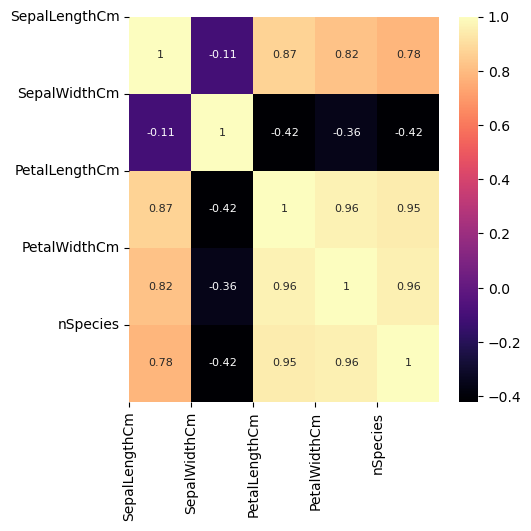

In [41]:
corr = df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(corr, cmap='magma', annot=True, annot_kws = {'fontsize': 8})
plt.xticks(range(len(corr.columns)), corr.columns)
plt.yticks(range(len(corr.columns)), corr.columns)

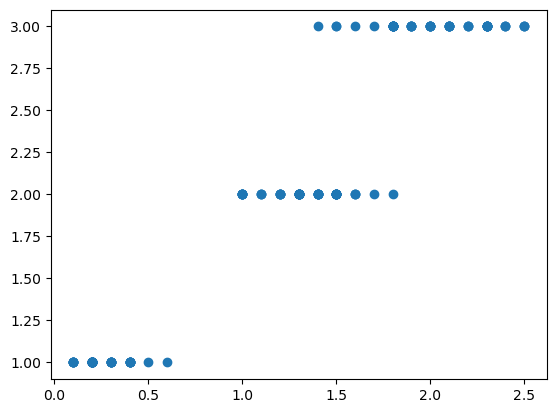

In [42]:
plt.scatter(df['PetalWidthCm'], df['nSpecies'])
plt.show()

In [43]:
print(y)

     nSpecies
0           1
1           1
2           1
3           1
4           1
..        ...
145         3
146         3
147         3
148         3
149         3

[150 rows x 1 columns]


In [44]:
y = y.to_numpy().ravel()

In [47]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42, stratify = y)#тестовая выборка не используется для подбора параметров, 

In [48]:
print(X_train.shape, X_test.shape)

(105, 4) (45, 4)


In [50]:
knn1 = KNeighborsClassifier(n_neighbors = 3)
knn1.fit(X_train, y_train)
y_pred = knn1.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(acc)

0.9111111111111111


# Кросс-валидация и подбор гиперпараметров

In [52]:
params = {
    'n_neighbors' : [3,5,7,9,11],
    'weights' : ['distance','uniform']
}
knn = KNeighborsClassifier()
grid_search = GridSearchCV(knn, params)
grid_search.fit(X_train, y_train)
print(grid_search.best_params_)
print(grid_search.best_score_)


{'n_neighbors': 9, 'weights': 'distance'}
0.9714285714285713
